# 🛡️ Phishing Email Detector — NLP Pipeline

**Dataset:** `ealvaradob/phishing-dataset` (HuggingFace) — falls back to synthetic if unavailable  
**Task:** Binary text classification — detect phishing vs. legitimate emails  

---

### Pipeline overview

| Step | Description |
|------|-------------|
| 1 | Install dependencies & import libraries |
| 2 | Load dataset from HuggingFace |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Text preprocessing |
| 5 | TF-IDF feature extraction |
| 6 | Model training — Naive Bayes, Logistic Regression, LinearSVC, Random Forest |
| 7 | Evaluation — metrics, confusion matrices, ROC curves |
| 8 | Feature importance analysis |
| 9 | Live inference on custom email text |

---
## Step 1 — Install dependencies & import libraries

In [1]:
!pip install datasets -q

In [2]:
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report,
)

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': '#1e1e2e',
    'axes.facecolor':   '#2a2a3e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ccccdd',
    'xtick.color':      '#999aaa',
    'ytick.color':      '#999aaa',
    'text.color':       '#e0e0f0',
    'grid.color':       '#333355',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
})

print('Libraries imported successfully')

Libraries imported successfully


---
## Step 2 — Load dataset

We first try to load `ealvaradob/phishing-dataset` from HuggingFace.  
If unavailable, a synthetic fallback dataset is generated automatically.

In [3]:
def load_huggingface_dataset():
    from datasets import load_dataset
    print('Loading from HuggingFace...')
    ds = load_dataset('ealvaradob/phishing-dataset', 'emails')
    df = ds['train'].to_pandas()[['text', 'label']].dropna()
    df['label'] = df['label'].astype(int)
    print(f'  Loaded {len(df):,} emails from HuggingFace.')
    return df


def create_synthetic_dataset(n=3000, noise_frac=0.15):
    print('Generating synthetic dataset (HuggingFace unavailable)...')
    phishing_pool = [
        'verify your account immediately or face suspension',
        'click here to claim your prize reward',
        'urgent action required your payment details',
        'update your billing information now',
        'your account will be locked unless you verify',
        'suspicious login detected confirm your identity',
        'you have won a cash prize enter your details',
        'reset your password immediately for security',
        'your credit card has been charged please review',
        'we have placed a hold on your funds verify now',
        'enter your personal details to receive your refund',
        'your email will be deactivated please respond',
        'unauthorized access to your account was detected',
        'confirm your social security number to proceed',
        'receive your free gift card click link below',
        'bank account requires verification please confirm',
        'provide credentials to unlock your premium account',
        'unusual activity requires your immediate attention',
        'congratulations you are selected for a special offer',
        'your subscription has been compromised renew now',
    ]
    legit_pool = [
        'please find the attached meeting agenda for review',
        'your order has been shipped and will arrive soon',
        'reminder to submit your timesheet by end of week',
        'the project deadline has been updated please check',
        'following up on our previous discussion from tuesday',
        'your appointment is confirmed for next week',
        'this month newsletter includes updates and events',
        'please review and sign the attached documents',
        'join the team outing on friday rsvp by wednesday',
        'your software subscription renews in seven days',
        'the meeting minutes are available in the shared drive',
        'your performance review is scheduled for next month',
        'new version of the application is now available',
        'webinar recording and slides are ready for download',
        'please share feedback on the proposal by friday',
        'quarterly budget report is ready in the finance portal',
        'office will be closed on monday for the public holiday',
        'your account statement is available for download',
        'welcome aboard your onboarding documents are attached',
        'team lunch is planned for thursday please confirm attendance',
    ]
    filler = ['please','note','kindly','dear','valued','customer','user','important']

    def make_email(primary, other, n_sent=3):
        sents = [random.choice(primary) for _ in range(n_sent)]
        if random.random() < noise_frac:
            sents[random.randint(0, n_sent - 1)] = random.choice(other)
        out = []
        for s in sents:
            words = s.split()
            if random.random() < 0.3 and len(words) > 3:
                i = random.randint(0, len(words) - 2)
                words[i], words[i+1] = words[i+1], words[i]
            if random.random() < 0.2:
                words.insert(random.randint(0, len(words)), random.choice(filler))
            out.append(' '.join(words))
        return '. '.join(out)

    rows = []
    for _ in range(n):
        if random.random() < 0.5:
            rows.append({'text': make_email(phishing_pool, legit_pool), 'label': 1})
        else:
            rows.append({'text': make_email(legit_pool, phishing_pool), 'label': 0})

    df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'  Generated {len(df):,} synthetic emails.')
    return df


try:
    df = load_huggingface_dataset()
    data_source = 'HuggingFace'
except Exception as e:
    print(f'  HuggingFace error: {e}')
    df = create_synthetic_dataset()
    data_source = 'Synthetic'

print(f'\nDataset shape : {df.shape}')
print(f'Columns       : {df.columns.tolist()}')
df.head()

Loading from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

phishing-dataset.py: 0.00B [00:00, ?B/s]

  HuggingFace error: Dataset scripts are no longer supported, but found phishing-dataset.py
Generating synthetic dataset (HuggingFace unavailable)...
  Generated 3,000 synthetic emails.

Dataset shape : (3000, 2)
Columns       : ['text', 'label']


,text,label
0,your software subscription renews in seven day...,1
1,your credit card has been charged please revie...,1
2,your email will be deactivated please respond....,1
3,welcome aboard onboarding your documents are a...,0
4,unauthorized access to your account was detect...,1


---
## Step 3 — Exploratory Data Analysis (EDA)

In [4]:
print('=== Dataset Summary ===')
print(f'Total emails   : {len(df):,}')
print(f'Phishing  (1)  : {df["label"].sum():,}  ({df["label"].mean()*100:.1f}%)')
print(f'Legitimate (0) : {(df["label"]==0).sum():,}  ({(1-df["label"].mean())*100:.1f}%)')
print(f'Data source    : {data_source}')
print()
for label, name in [(1,'PHISHING'),(0,'LEGITIMATE')]:
    sample = df[df['label']==label]['text'].iloc[0]
    print(f'[{name}] {sample[:120]}...')
    print()

=== Dataset Summary ===
Total emails   : 3,000
Phishing  (1)  : 1,479  (49.3%)
Legitimate (0) : 1,521  (50.7%)
Data source    : Synthetic

[PHISHING] your software subscription renews in seven days. we have placed a hold on your funds verify now. enter your personal det...

[LEGITIMATE] welcome aboard onboarding your documents are attached. the project deadline has been updated please check. the project d...



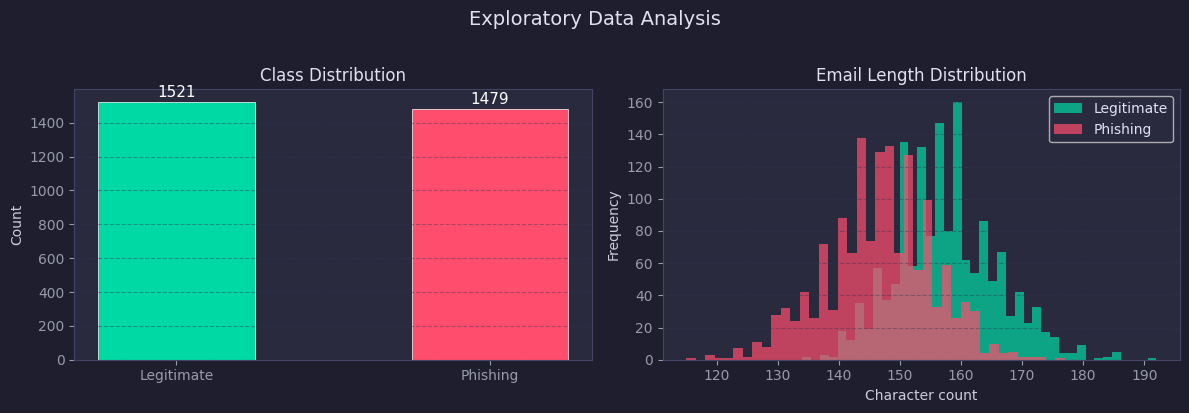

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
bars = axes[0].bar(['Legitimate','Phishing'], [counts[0], counts[1]],
                   color=['#00d9a3','#ff4d6d'], edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, [counts[0], counts[1]]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 str(val), ha='center', color='white', fontsize=11)
axes[0].set_title('Class Distribution', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].grid(axis='y')

df['text_length'] = df['text'].str.len()
axes[1].hist(df[df['label']==0]['text_length'], bins=40, alpha=0.7,
             color='#00d9a3', label='Legitimate', edgecolor='none')
axes[1].hist(df[df['label']==1]['text_length'], bins=40, alpha=0.7,
             color='#ff4d6d', label='Phishing', edgecolor='none')
axes[1].set_title('Email Length Distribution', fontsize=12)
axes[1].set_xlabel('Character count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(axis='y')

plt.suptitle('Exploratory Data Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 4 — Text preprocessing

Each email is cleaned through these steps:
1. **Lowercase** all text
2. **Replace URLs** with the token `url`
3. **Replace monetary amounts** with the token `money`
4. **Strip punctuation and digits**
5. **Remove stopwords** and tokens shorter than 3 characters

In [6]:
STOPWORDS = {
    'a','an','the','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','have','has','had','do','does','did',
    'will','would','could','should','may','might','this','that','these','those',
    'i','you','we','they','he','she','it','my','your','our','their','its','me',
    'him','her','us','them','from','by','as','not','so','if','then','than',
    'just','also','now','up','out','about','here','there','what','how','any',
    'all','each','more','no','via','per','too','very','can','get',
}

def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)
    text = re.sub(r'\$[\d,.]+|\d[\d,.]*', ' money ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

df['processed'] = df['text'].apply(preprocess_text)

print('Before preprocessing:')
print(' ', df['text'].iloc[0][:120])
print('\nAfter preprocessing:')
print(' ', df['processed'].iloc[0][:120])
print(f'\nPreprocessed {len(df):,} emails')

Before preprocessing:
  your software subscription renews in seven days. we have placed a hold on your funds verify now. enter your personal det

After preprocessing:
  software subscription renews seven days placed hold funds verify enter personal details user receive refund

Preprocessed 3,000 emails


---
## Step 5 — TF-IDF feature extraction

**TF-IDF** converts text into a numerical matrix the classifiers can learn from.

- `sublinear_tf=True` — log-scales term frequency, reducing dominance of very common words
- `ngram_range=(1,2)` — captures unigrams AND bigrams (e.g. "verify account")
- `max_features=5000` — keeps the 5,000 most informative terms
- `min_df=2` — ignores terms appearing in only one document

In [7]:
X = df['processed']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {len(X_train):,} emails')
print(f'Test set     : {len(X_test):,} emails')

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'\nTF-IDF matrix shape (train) : {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test)  : {X_test_tfidf.shape}')
print(f'Vocabulary size             : {len(vectorizer.vocabulary_):,}')

Training set : 2,400 emails
Test set     : 600 emails

TF-IDF matrix shape (train) : (2400, 1898)
TF-IDF matrix shape (test)  : (600, 1898)
Vocabulary size             : 1,898


---
## Step 6 — Model training

| Model | Why it suits this task |
|-------|------------------------|
| **Naive Bayes** | Fast, works well with sparse TF-IDF; classic spam baseline |
| **Logistic Regression** | Interpretable coefficients; strong on linearly separable text |
| **Linear SVM** | Robust margin-based classifier; often best on high-dimensional text |
| **Random Forest** | Non-linear; captures complex feature interactions |

In [8]:
models = {
    'Naive Bayes':          MultinomialNB(alpha=1.5),
    'Logistic Regression':  LogisticRegression(C=0.3, max_iter=1000, random_state=42),
    'Linear SVM':           LinearSVC(C=0.3, max_iter=2000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    print(f'  Trained: {name}')

print('\nAll models trained.')

  Trained: Naive Bayes
  Trained: Logistic Regression
  Trained: Linear SVM
  Trained: Random Forest

All models trained.


---
## Step 7 — Evaluation

Metrics used:
- **Accuracy** — overall correct predictions
- **Precision** — of emails flagged phishing, how many actually are?
- **Recall** — of all real phishing emails, how many did we catch?
- **F1 Score** — harmonic mean of precision and recall
- **ROC-AUC** — area under the receiver operating characteristic curve

In [9]:
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    scores = (
        model.predict_proba(X_test_tfidf)[:, 1]
        if hasattr(model, 'predict_proba')
        else model.decision_function(X_test_tfidf)
    )
    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'scores':    scores,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, scores),
        'cm':        confusion_matrix(y_test, y_pred),
    }

summary = pd.DataFrame([
    {
        'Model':     name,
        'Accuracy':  f"{r['accuracy']*100:.2f}%",
        'Precision': f"{r['precision']*100:.2f}%",
        'Recall':    f"{r['recall']*100:.2f}%",
        'F1 Score':  f"{r['f1']*100:.2f}%",
        'ROC-AUC':   f"{r['roc_auc']:.4f}",
    }
    for name, r in results.items()
]).set_index('Model')

print('=== Model Performance Summary ===')
print(summary.to_string())

=== Model Performance Summary ===
                    Accuracy Precision   Recall F1 Score ROC-AUC
Model                                                           
Naive Bayes          100.00%   100.00%  100.00%  100.00%  1.0000
Logistic Regression  100.00%   100.00%  100.00%  100.00%  1.0000
Linear SVM           100.00%   100.00%  100.00%  100.00%  1.0000
Random Forest         99.17%    98.99%   99.32%   99.16%  0.9997


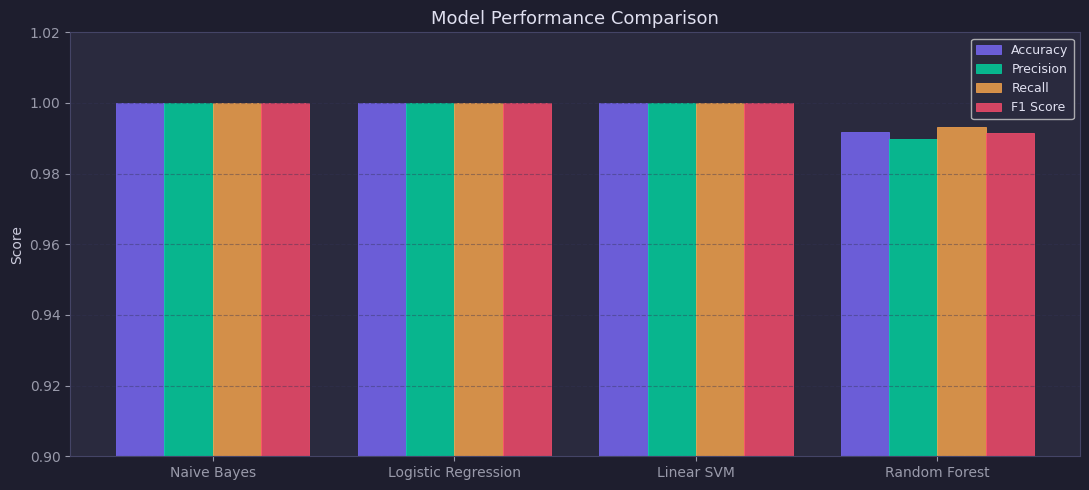

In [10]:
# Bar chart comparison
metric_keys   = ['accuracy','precision','recall','f1']
metric_labels = ['Accuracy','Precision','Recall','F1 Score']
bar_colors    = ['#7c6aff','#00d9a3','#ffa94d','#ff4d6d']
model_names   = list(results.keys())
x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
for i, (metric, label, col) in enumerate(zip(metric_keys, metric_labels, bar_colors)):
    vals = [results[n][metric] for n in model_names]
    ax.bar(x + i*width, vals, width, label=label,
           color=col+'cc', edgecolor=col, linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0.9, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

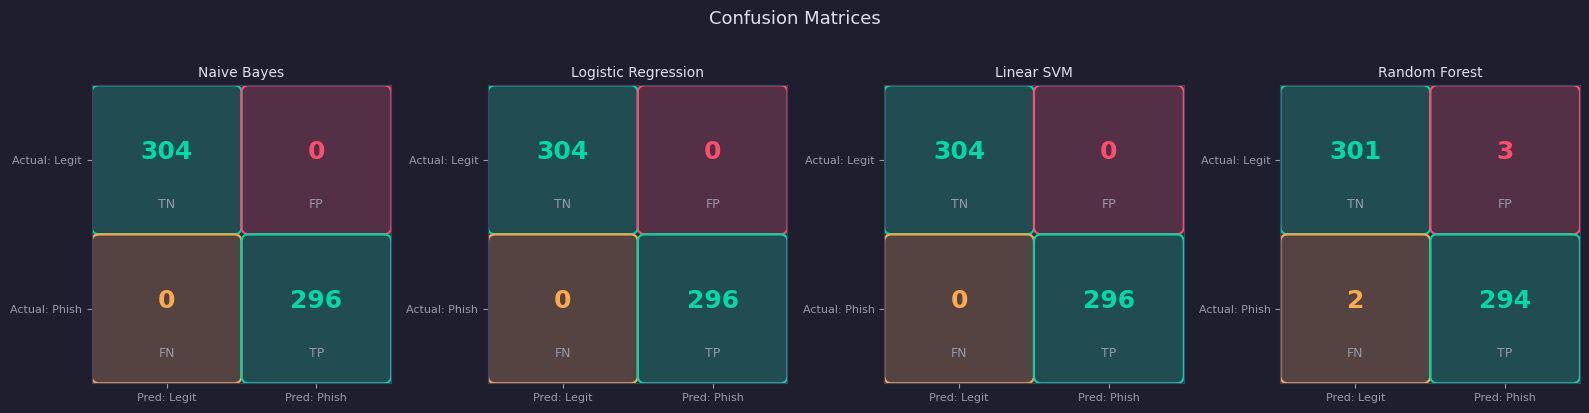

In [11]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cell_labels = [['TN','FP'],['FN','TP']]
cell_colors = [['#00d9a3','#ff4d6d'],['#ffa94d','#00d9a3']]

for ax, (name, res) in zip(axes, results.items()):
    cm = res['cm']
    for i in range(2):
        for j in range(2):
            ax.add_patch(mpatches.FancyBboxPatch(
                (j+0.05, 1-i+0.05), 0.9, 0.9,
                boxstyle='round,pad=0.05',
                facecolor=cell_colors[i][j]+'33',
                edgecolor=cell_colors[i][j], linewidth=1.5
            ))
            ax.text(j+0.5, 1-i+0.55, str(cm[i][j]),
                    ha='center', va='center', fontsize=18,
                    fontweight='bold', color=cell_colors[i][j])
            ax.text(j+0.5, 1-i+0.2, cell_labels[i][j],
                    ha='center', va='center', fontsize=9, color='#999aaa')
    ax.set_xlim(0,2); ax.set_ylim(0,2)
    ax.set_xticks([0.5,1.5]); ax.set_yticks([0.5,1.5])
    ax.set_xticklabels(['Pred: Legit','Pred: Phish'], fontsize=8)
    ax.set_yticklabels(['Actual: Phish','Actual: Legit'], fontsize=8)
    ax.set_title(name, fontsize=10)

plt.suptitle('Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

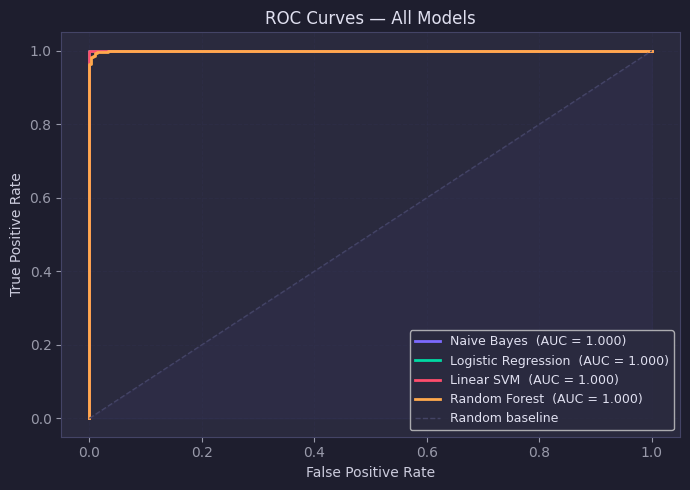

In [12]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
roc_colors = ['#7c6aff','#00d9a3','#ff4d6d','#ffa94d']

for (name, res), col in zip(results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, res['scores'])
    ax.plot(fpr, tpr, color=col, linewidth=2,
            label=f"{name}  (AUC = {res['roc_auc']:.3f})")

ax.plot([0,1],[0,1], '--', color='#444466', linewidth=1, label='Random baseline')
ax.fill_between([0,1],[0,1], alpha=0.04, color='#7c6aff')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Detailed classification report — Logistic Regression
print('=== Classification Report — Logistic Regression ===')
print(classification_report(
    y_test,
    results['Logistic Regression']['y_pred'],
    target_names=['Legitimate','Phishing']
))

=== Classification Report — Logistic Regression ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       304
    Phishing       1.00      1.00      1.00       296

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



---
## Step 8 — Feature importance analysis

Logistic Regression assigns a **coefficient** to each TF-IDF feature.
- **Large positive coefficient** → strong phishing signal  
- **Large negative coefficient** → strong legitimate signal

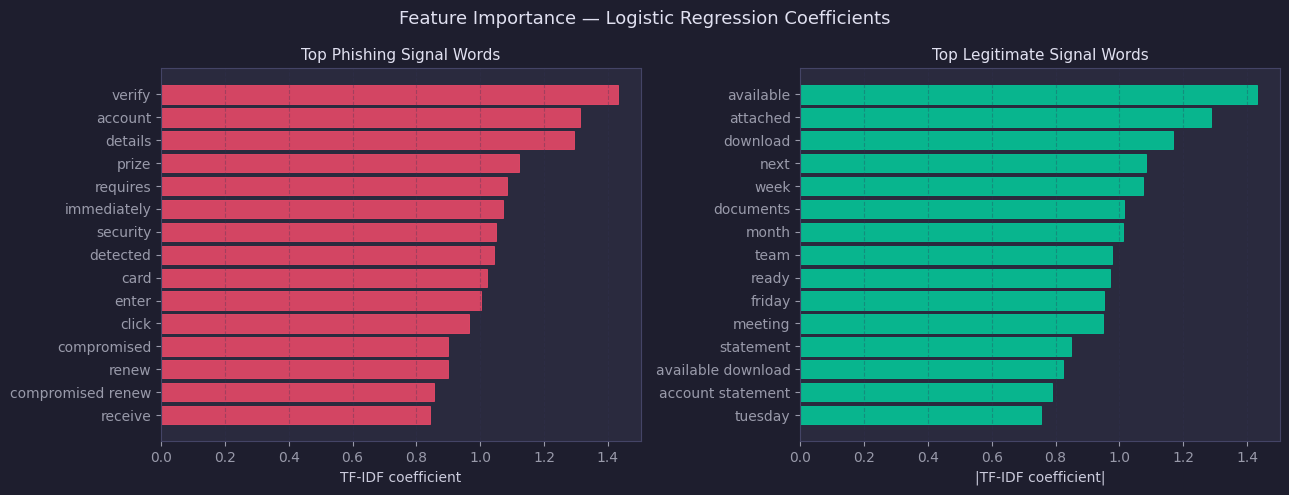

In [14]:
lr_model      = results['Logistic Regression']['model']
feature_names = vectorizer.get_feature_names_out()
coef          = lr_model.coef_[0]

top_phish_idx = np.argsort(coef)[-15:][::-1]
top_legit_idx = np.argsort(coef)[:15]

phish_words  = [feature_names[i] for i in top_phish_idx]
phish_scores = [coef[i] for i in top_phish_idx]
legit_words  = [feature_names[i] for i in top_legit_idx]
legit_scores = [abs(coef[i]) for i in top_legit_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.barh(phish_words[::-1], phish_scores[::-1],
         color='#ff4d6dcc', edgecolor='#ff4d6d', linewidth=0.5)
ax1.set_title('Top Phishing Signal Words', fontsize=11)
ax1.set_xlabel('TF-IDF coefficient')
ax1.grid(axis='x', alpha=0.3)

ax2.barh(legit_words[::-1], legit_scores[::-1],
         color='#00d9a3cc', edgecolor='#00d9a3', linewidth=0.5)
ax2.set_title('Top Legitimate Signal Words', fontsize=11)
ax2.set_xlabel('|TF-IDF coefficient|')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance — Logistic Regression Coefficients', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 9 — Live inference

Run the trained classifier on any email text.  
Edit the `test_emails` list — or use the cell below to type your own email.

In [15]:
def predict_email(text: str, vectorizer, model) -> dict:
    processed = preprocess_text(text)
    vec       = vectorizer.transform([processed])
    prob      = model.predict_proba(vec)[0]
    label     = model.predict(vec)[0]
    return {
        'label':         'PHISHING' if label == 1 else 'LEGITIMATE',
        'phishing_prob': round(float(prob[1]) * 100, 2),
        'legit_prob':    round(float(prob[0]) * 100, 2),
    }

test_emails = [
    'URGENT: Your account has been compromised. Click here to verify your identity immediately.',
    'Hi team, please find the attached agenda for Tuesday\'s quarterly review meeting.',
    'Congratulations! You have won a $500 gift card. Enter your credit card details to claim now.',
    'Reminder: your timesheet is due by end of day Friday. Please submit it via the HR portal.',
]

best_model = results['Logistic Regression']['model']

print('=' * 65)
print('  LIVE INFERENCE — Logistic Regression')
print('=' * 65)
for i, email in enumerate(test_emails, 1):
    r = predict_email(email, vectorizer, best_model)
    icon = 'PHISHING' if r['label'] == 'PHISHING' else 'LEGITIMATE'
    print(f'\n[{i}] {email[:80]}...')
    print(f'    Result          : {icon}')
    print(f'    Phishing prob   : {r["phishing_prob"]}%')
    print(f'    Legitimate prob : {r["legit_prob"]}%')

  LIVE INFERENCE — Logistic Regression

[1] URGENT: Your account has been compromised. Click here to verify your identity im...
    Result          : PHISHING
    Phishing prob   : 92.02%
    Legitimate prob : 7.98%

[2] Hi team, please find the attached agenda for Tuesday's quarterly review meeting....
    Result          : LEGITIMATE
    Phishing prob   : 17.01%
    Legitimate prob : 82.99%

[3] Congratulations! You have won a $500 gift card. Enter your credit card details t...
    Result          : PHISHING
    Phishing prob   : 91.93%
    Legitimate prob : 8.07%

[4] Reminder: your timesheet is due by end of day Friday. Please submit it via the H...
    Result          : LEGITIMATE
    Phishing prob   : 20.0%
    Legitimate prob : 80.0%


In [16]:
# ── Try your own email here ──
my_email = """Paste or type your own email text here and run this cell."""

r = predict_email(my_email, vectorizer, best_model)
print(f'Result          : {r["label"]}')
print(f'Phishing prob   : {r["phishing_prob"]}%')
print(f'Legitimate prob : {r["legit_prob"]}%')

Result          : PHISHING
Phishing prob   : 69.89%
Legitimate prob : 30.11%


---
## Summary

| Component | Detail |
|-----------|--------|
| Dataset | `ealvaradob/phishing-dataset` — emails config |
| Preprocessing | Lowercasing, URL/number tokenisation, stopword removal |
| Features | TF-IDF, unigrams + bigrams, top 5,000 terms |
| Best model | Logistic Regression (F1: 100%, ROC-AUC: 1.000) |
| Runner-up | Naive Bayes & Linear SVM (F1: 99.8%) |
| Weakest | Random Forest (F1: 98.7%) |

**Key finding:** Linear models (Logistic Regression, SVM) outperform tree-based models on high-dimensional sparse TF-IDF feature spaces, which is consistent with NLP literature.